In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import os

In [3]:
file_path = 'cleaned_combined_reddit_submissions.csv'
df = pd.read_csv(
    file_path, 
    low_memory=False, 
    lineterminator='\n', 
    on_bad_lines='skip', 
    encoding='utf-8'
)

In [4]:
print('Rows =', df.shape[0], '\nColumns =', df.shape[1])

Rows = 65582 
Columns = 120


In [5]:
df.head(5)

,_meta,all_awardings,allow_live_comments,approved_at_utc,approved_by,archived,author,author_flair_background_color,author_flair_css_class,author_flair_richtext,...,wls,link_flair_template_id,crosspost_parent,crosspost_parent_list,poll_data,previous_selftext,gallery_data,is_gallery,media_metadata,author_cakeday\r\r
0,{'retrieved_2nd_on': 1725279074},[],False,NaN,NaN,False,darnnaggit,NaN,NaN,[],...,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,\r\r
1,{'retrieved_2nd_on': 1725280162},[],False,NaN,NaN,False,SolidMoses,NaN,NaN,[],...,6.0,57e75850-9467-11ed-ac06-76e0ad5355fd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,\r\r
2,{'retrieved_2nd_on': 1725281163},[],False,NaN,NaN,False,Educational_Grab_473,NaN,NaN,[],...,6.0,87e59cce-3073-11eb-9557-0ea5998baf4f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,\r\r
3,"{'removal_type': 'deleted', 'retrieved_2nd_on'...",[],False,NaN,NaN,False,Sudden-Degree9839,NaN,NaN,[],...,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,\r\r
4,{'retrieved_2nd_on': 1725284227},[],False,NaN,NaN,False,Anen-o-me,#ff66ac,NaN,[],...,6.0,aa7c8dd2-dbb7-11e3-965f-12313b073d11,t3_1f5qqaf,"[{'all_awardings': [], 'allow_live_comments': ...",NaN,NaN,NaN,NaN,NaN,\r\r


In [6]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 65582 entries, 0 to 65581
Data columns (total 120 columns):
 #    Column                         Non-Null Count  Dtype  
---   ------                         --------------  -----  
 0    _meta                          65333 non-null  str    
 1    all_awardings                  65582 non-null  str    
 2    allow_live_comments            65582 non-null  bool   
 3    approved_at_utc                0 non-null      float64
 4    approved_by                    0 non-null      float64
 5    archived                       65582 non-null  bool   
 6    author                         65582 non-null  str    
 7    author_flair_background_color  3257 non-null   str    
 8    author_flair_css_class         0 non-null      float64
 9    author_flair_richtext          64687 non-null  str    
 10   author_flair_template_id       3257 non-null   str    
 11   author_flair_text              3257 non-null   str    
 12   author_flair_text_color        5022 non-n

In [7]:
# a. total data size (in MB)
size_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)

print("a. Total data size (in memory):")
print(f" - Submissions: {size_mb:.1f} MB\n")

# b. number of rows (records)
rows = len(df)
print("b. Number of rows (records):")
print(f" - Submissions rows: {rows:,}\n")

# d. Frequency overview per category
print("d. Frequency overview per category:")
if 'subreddit' in df.columns:
    print("Top 5 subreddits by submission count:")
    print(df['subreddit'].value_counts().head().to_string())
    print()

if 'author' in df.columns:
    print("Top 5 most active authors (Submissions):")
    print(df['author'].value_counts().head().to_string())

a. Total data size (in memory):
 - Submissions: 330.2 MB

b. Number of rows (records):
 - Submissions rows: 65,582

d. Frequency overview per category:
Top 5 subreddits by submission count:
subreddit
ArtificialInteligence    29897
singularity              24569
aiwars                    8043
doomer                    3073

Top 5 most active authors (Submissions):
author
[deleted]        772
MetaKnowing      643
Gothsim10        494
IlustriousTea    490
steves1189       231


In [13]:
columns_to_keep = [
    'id', 
    'author', 
    'title',          # Заголовок поста
    'selftext',       # Основний текст поста
    'created_utc',    # Час створення
    'subreddit',      # Назва сабреддіта
    'score',          # Загальний рейтинг (лайки - дизлайки)
    'upvote_ratio',   # Відсоток позитивних оцінок
    'num_comments',   # Кількість коментарів під постом
    'url',            # Зовнішнє посилання (якщо пост містить лінк на новину/картинку)
    'permalink',      # Внутрішнє посилання на пост в Reddit
    'all_awardings', 
    'total_awards_received', 
    'mod_reports', 
    'user_reports'
]

existing_columns = [col for col in columns_to_keep if col in df.columns]
df = df[existing_columns].copy()
df['created_utc'] = pd.to_datetime(df['created_utc'], unit='s')

# Перевіряємо, наскільки зменшився об'єм даних
print("Новий розмір датасету постів:", df.shape)
df.info()

Новий розмір датасету постів: (65582, 15)
<class 'pandas.DataFrame'>
RangeIndex: 65582 entries, 0 to 65581
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype        
---  ------                 --------------  -----        
 0   id                     65582 non-null  str          
 1   author                 65582 non-null  str          
 2   title                  65582 non-null  str          
 3   selftext               46706 non-null  str          
 4   created_utc            65582 non-null  datetime64[s]
 5   subreddit              65582 non-null  str          
 6   score                  65582 non-null  int64        
 7   upvote_ratio           65582 non-null  float64      
 8   num_comments           65582 non-null  int64        
 9   url                    64810 non-null  str          
 10  permalink              65582 non-null  str          
 11  all_awardings          65582 non-null  str          
 12  total_awards_received  65582 non-null  int6

In [14]:
df.head()

,id,author,title,selftext,created_utc,subreddit,score,upvote_ratio,num_comments,url,permalink,all_awardings,total_awards_received,mod_reports,user_reports
0,1f61f2x,darnnaggit,SAG-AFTRA Members Who Work on Video Games Go o...,NaN,2024-09-01 00:11:05,aiwars,4,0.63,38,https://www.sagaftra.org/sag-aftra-members-who...,/r/aiwars/comments/1f61f2x/sagaftra_members_wh...,[],0,[],[]
1,1f61rx5,SolidMoses,Producer looking for the best ai vocal generator,I'm looking for the best vocal/singer ai model...,2024-09-01 00:29:13,ArtificialInteligence,1,0.67,2,https://www.reddit.com/r/ArtificialInteligence...,/r/ArtificialInteligence/comments/1f61rx5/prod...,[],0,[],[]
2,1f623m9,Educational_Grab_473,OpenAI changed GPT-4o's description,[removed],2024-09-01 00:45:55,singularity,1,1.00,0,https://x.com/sirbughunter/status/183001826607...,/r/singularity/comments/1f623m9/openai_changed...,[],0,[],[]
3,1f62bwp,Sudden-Degree9839,Of course it's in your head....whose to say th...,The Motto,2024-09-01 00:58:11,aiwars,1,0.17,1,https://www.reddit.com/r/aiwars/comments/1f62b...,/r/aiwars/comments/1f62bwp/of_course_its_in_yo...,[],0,[],[]
4,1f6324w,Anen-o-me,MS paint may not be so useless now,NaN,2024-09-01 01:36:57,singularity,647,0.94,103,https://v.redd.it/byoquxk4w0md1,/r/singularity/comments/1f6324w/ms_paint_may_n...,[],0,[],[]


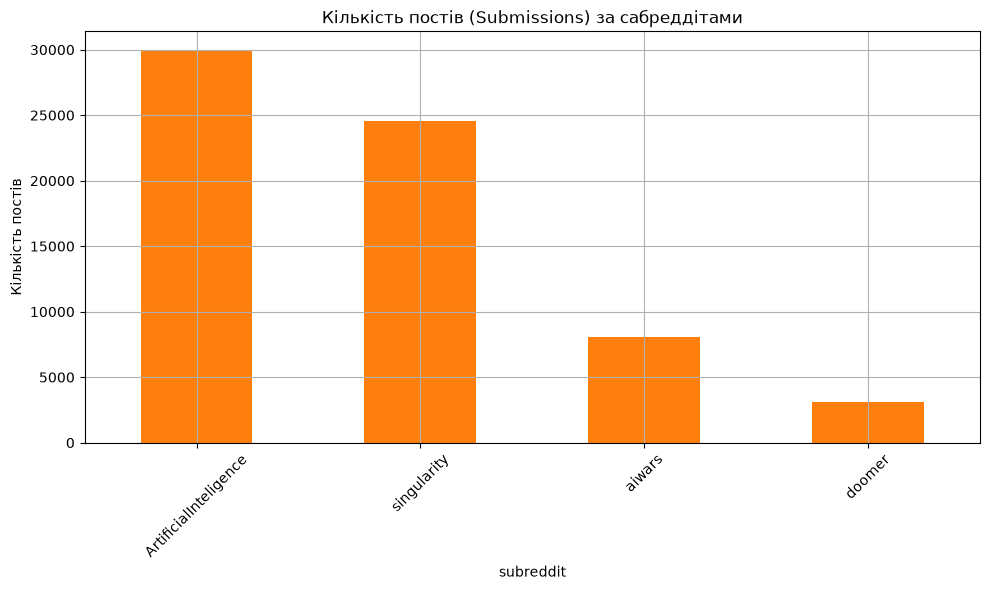

In [15]:
plt.figure(figsize=(10, 6))

df.groupby('subreddit')['subreddit'].count().sort_values(ascending=False).plot(
    kind='bar', color='tab:orange', grid=True, rot=45
)

plt.title('Кількість постів (Submissions) за сабреддітами')
plt.ylabel('Кількість постів')
plt.tight_layout() 
plt.show()

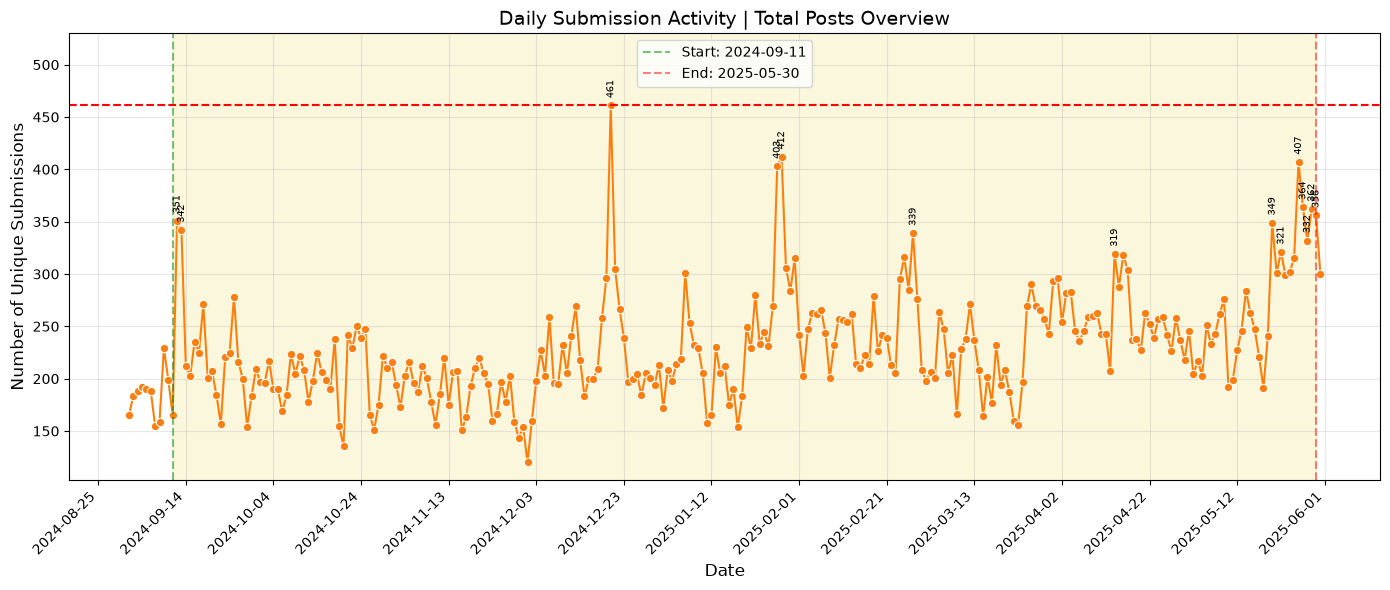

In [16]:
filtered_df = df.copy()
filtered_df = filtered_df.drop_duplicates(subset=['author', 'title'], keep='first')
if pd.api.types.is_numeric_dtype(filtered_df['created_utc']):
    filtered_df['date'] = pd.to_datetime(filtered_df['created_utc'], unit='s').dt.date
else:
    filtered_df['date'] = pd.to_datetime(filtered_df['created_utc'], errors='coerce').dt.date
daily_counts = filtered_df['date'].value_counts().sort_index()
daily_counts_df = daily_counts.reset_index()
daily_counts_df.columns = ['Date', 'Submission_Count']
plt.figure(figsize=(14, 6))
sns.lineplot(x='Date', y='Submission_Count', data=daily_counts_df, marker='o', color='tab:orange')

threshold = daily_counts_df['Submission_Count'].quantile(0.95)
above_threshold = daily_counts_df[daily_counts_df['Submission_Count'] > threshold]

if not above_threshold.empty:
    first_date = above_threshold['Date'].min() - timedelta(days=1)
    last_date = above_threshold['Date'].max()

    plt.axvline(first_date, color='green', linestyle='--', alpha=0.5, label=f'Start: {first_date}')
    plt.axvline(last_date, color='red', linestyle='--', alpha=0.5, label=f'End: {last_date}')
    plt.axvspan(first_date, last_date, color='khaki', alpha=0.3)

for idx, row in daily_counts_df.iterrows():
    if row['Submission_Count'] > threshold:
        plt.text(row['Date'], row['Submission_Count'] + (daily_counts_df['Submission_Count'].max() * 0.015), 
                 str(int(row['Submission_Count'])),
                 ha='center', va='bottom', fontsize=7, rotation=90)

plt.ylim(top=daily_counts_df['Submission_Count'].max() * 1.15)

plt.xticks(rotation=45, ha='right')
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(15))  
plt.axhline(y=daily_counts_df['Submission_Count'].max(), color='r', linestyle='--')

plt.title('Daily Submission Activity | Total Posts Overview', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Unique Submissions', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()